In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error



In [2]:
#load and preprocess data


# 1. Load the data from CSV files
train_data = pd.read_csv('../poly_regression_small.csv')
test_data = pd.read_csv('../poly_regression_large.csv')

# Split the training and test data
X_train = train_data.iloc[:, 1].values.reshape(-1, 1)  # Extract the 'x' column and reshape
y_train = train_data.iloc[:, 2].values  # Extract the 'y' column

# Sample 20% of the large dataset for the test set
test_data_sample = test_data.sample(frac=0.2, random_state=42)

X_test = test_data_sample.iloc[:, 1].values.reshape(-1, 1)  # Extract the 'x' column for test set
y_test = test_data_sample.iloc[:, 2].values  # Extract the 'y' column for test set

# 2. Preprocessing: Scaling the input data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## MLE

Error (GD): 0.03256552231791366
Error (SGD): 0.03271853317993094
Error (Normal Eq with Regularization): 0.032565524204974154


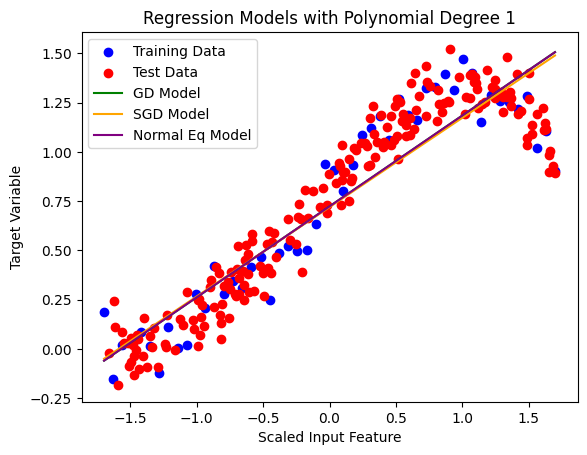

/Users/negin/.pyenv/versions/3.12.0/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/ly/lpbxvjvn2lz41cth817v1n700000gn/T/ipykernel_1416/683925084.py:48: RuntimeWarning: overflow encountered in square
  error = np.mean((predictions - y)**2)
/var/folders/ly/lpbxvjvn2lz41cth817v1n700000gn/T/ipykernel_1416/683925084.py:28: RuntimeWarning: invalid value encountered in subtract
  theta -= lr * gradients
/Users/negin/.pyenv/versions/3.12.0/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/ly/lpbxvjvn2lz41cth817v1n700000gn/T/ipykernel_1416/683925084.py:48: RuntimeWarning: overflow encountered in square
  error = np.mean((predictions - y)**2)
/var/folders/ly/lpbxvjvn2lz41cth817v1n700000gn/T/ipykernel_1416/683925084.py:14: RuntimeWarning: 

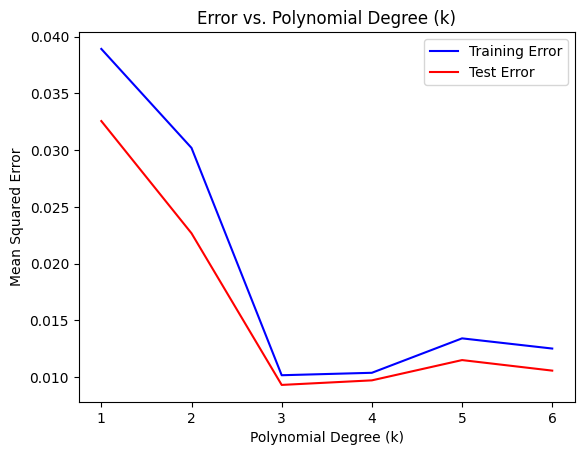

In [30]:
#with predifined function create_polynomial_features
# 3. Polynomial Features: Adding polynomial terms of degree k
def create_polynomial_features(X, k):
    poly = PolynomialFeatures(degree=k)
    return poly.fit_transform(X)

# 4. Gradient Descent Implementation
def gradient_descent(X, y, lr=0.01, epochs=1000):
    m = len(y)
    theta = np.zeros(X.shape[1])  # Initialize theta
    error_history = []  # To store error at each iteration
    for _ in range(epochs):
        gradients = (2/m) * X.T.dot(X.dot(theta) - y)
        theta -= lr * gradients
        error_history.append(compute_error(X, y, theta))  # Store error at each step
    return theta, error_history

# 5. Stochastic Gradient Descent Implementation
def stochastic_gradient_descent(X, y, lr=0.01, epochs=1000, batch_size=5):
    m = len(y)
    theta = np.zeros(X.shape[1])  # Initialize theta
    error_history = []  # To store error at each iteration
    for _ in range(epochs):
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            gradients = (2/batch_size) * X_batch.T.dot(X_batch.dot(theta) - y_batch)
            theta -= lr * gradients
        error_history.append(compute_error(X, y, theta))  # Store error at each step
    return theta, error_history

# 6. Normal Equations with Cholesky Decomposition (with regularization)
def normal_equations_cholesky_regularized(X, y, lambda_=1e-5):
    X_transpose = X.T
    A = X_transpose.dot(X) + lambda_ * np.eye(X.shape[1])  # Add lambda * I to ensure positive definiteness
    b = X_transpose.dot(y)
    try:
        L = np.linalg.cholesky(A)  # Perform Cholesky decomposition
        theta = np.linalg.solve(L.T, np.linalg.solve(L, b))  # Solve for theta
    except np.linalg.LinAlgError:
        print("Cholesky decomposition failed due to non-positive definite matrix.")
        return None
    return theta

# 7. Error Calculation: Mean Squared Error (MSE)
def compute_error(X, y, theta):
    predictions = X.dot(theta)
    error = np.mean((predictions - y)**2)
    return error

# Polynomial degree k (e.g., 3 for cubic)
k = 1

# Create polynomial features
X_train_poly = create_polynomial_features(X_train_scaled, k)
X_test_poly = create_polynomial_features(X_test_scaled, k)

# Train the models
theta_gd, error_gd_history = gradient_descent(X_train_poly, y_train, lr=0.01, epochs=1000)
theta_sgd, error_sgd_history = stochastic_gradient_descent(X_train_poly, y_train, lr=0.01, epochs=1000, batch_size=5)
theta_ne_regularized = normal_equations_cholesky_regularized(X_train_poly, y_train, lambda_=1e-5)

# Compute errors for each model
error_gd = compute_error(X_test_poly, y_test, theta_gd)
error_sgd = compute_error(X_test_poly, y_test, theta_sgd)
error_ne_regularized = compute_error(X_test_poly, y_test, theta_ne_regularized)

# Print the errors
print(f"Error (GD): {error_gd}")
print(f"Error (SGD): {error_sgd}")
print(f"Error (Normal Eq with Regularization): {error_ne_regularized}")

# 8. Visualization of the Models
# Generate x values for plotting the regression curves
x_vals = np.linspace(X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max(), 100).reshape(-1, 1)

# Create polynomial features for the generated x values
x_vals_poly = create_polynomial_features(x_vals, k)

# Calculate predicted values from each model
y_vals_gd = x_vals_poly.dot(theta_gd)
y_vals_sgd = x_vals_poly.dot(theta_sgd)
y_vals_ne = x_vals_poly.dot(theta_ne_regularized)

# Plot the regression models
plt.scatter(X_train_scaled, y_train, color='blue', label='Training Data')  # Scatter plot for training data
plt.scatter(X_test_scaled, y_test, color='red', label='Test Data')  # Scatter plot for test data
plt.plot(x_vals, y_vals_gd, label='GD Model', color='green')
plt.plot(x_vals, y_vals_sgd, label='SGD Model', color='orange')
plt.plot(x_vals, y_vals_ne, label='Normal Eq Model', color='purple')
plt.legend()
plt.xlabel('Scaled Input Feature')
plt.ylabel('Target Variable')
plt.title(f'Regression Models with Polynomial Degree {k}')
plt.show()

# Optionally, plot the error comparison with respect to the polynomial degree
k_values = np.arange(1, 10)  # Experiment with different polynomial degrees
train_errors = []
test_errors = []

for k in k_values:
    # Create polynomial features for the current degree k
    X_train_poly_k = create_polynomial_features(X_train_scaled, k)
    X_test_poly_k = create_polynomial_features(X_test_scaled, k)
    
    # Train and test the models for each k value
    theta_gd_k, _ = gradient_descent(X_train_poly_k, y_train, lr=0.01, epochs=1000)
    theta_sgd_k, _ = stochastic_gradient_descent(X_train_poly_k, y_train, lr=0.01, epochs=1000, batch_size=5)
    theta_ne_k = normal_equations_cholesky_regularized(X_train_poly_k, y_train, lambda_=1e-5)

    # Compute errors
    train_errors.append(compute_error(X_train_poly_k, y_train, theta_gd_k))
    test_errors.append(compute_error(X_test_poly_k, y_test, theta_gd_k))

# Plot the errors
plt.plot(k_values, train_errors, label='Training Error', color='blue')
plt.plot(k_values, test_errors, label='Test Error', color='red')
plt.xlabel('Polynomial Degree (k)')
plt.ylabel('Mean Squared Error')
plt.title('Error vs. Polynomial Degree (k)')
plt.legend()
plt.show()

Error (GD): 0.009770245177886203
Error (SGD): 0.010610261472370899
Error (Normal Eq ): 0.010592830527025336


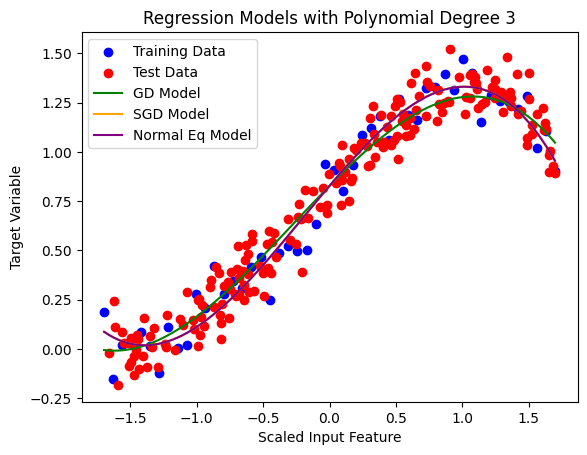

In [31]:


# 3. Polynomial Features: Adding polynomial terms of degree k
def create_polynomial_features_m(X, k):
    n_samples, n_features = X.shape
    features = [np.ones(n_samples)]
    for d in range(1, k + 1):
        for comb in itertools.combinations_with_replacement(range(n_features), d):
            term = np.prod([X[:, i] ** (comb.count(i)) for i in range(n_features)], axis=0)
            features.append(term)
    poly_features = np.column_stack(features)
    # Normalize the polynomial features
    poly_features[:, 1:] = StandardScaler().fit_transform(poly_features[:, 1:])
    return poly_features

# 4. Gradient Descent Implementation
def gradient_descent(X, y, lr=0.01, epochs=1000):
    m = len(y)
    theta = np.zeros(X.shape[1])  # Initialize theta
    error_history = []  # To store error at each iteration
    for _ in range(epochs):
        gradients = (2/m) * X.T.dot(X.dot(theta) - y)
        theta -= lr * gradients
        error_history.append(compute_error(X, y, theta))  # Store error at each step
    return theta, error_history

# 5. Stochastic Gradient Descent Implementation
def stochastic_gradient_descent(X, y, lr=0.01, epochs=1000, batch_size=5):
    m = len(y)
    theta = np.zeros(X.shape[1])  # Initialize theta
    error_history = []  # To store error at each iteration
    for _ in range(epochs):
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            gradients = (2/batch_size) * X_batch.T.dot(X_batch.dot(theta) - y_batch)
            theta -= lr * gradients
        error_history.append(compute_error(X, y, theta))  # Store error at each step
    return theta, error_history

# 6. Normal Equations with Cholesky Decomposition (with regularization)
def normal_equations_cholesky_mle(X, y):
    X_transpose = X.T
    A = X_transpose.dot(X)  # No regularization for MLE
    b = X_transpose.dot(y)
    try:
        L = np.linalg.cholesky(A)  # Perform Cholesky decomposition
        theta = np.linalg.solve(L.T, np.linalg.solve(L, b))  # Solve for theta
    except np.linalg.LinAlgError:
        print("Cholesky decomposition failed due to non-positive definite matrix.")
        return None
    return theta

# 7. Error Calculation: Mean Squared Error (MSE)
def compute_error(X, y, theta):
    predictions = X.dot(theta)
    error = np.mean((predictions - y)**2)
    return error
# Polynomial degree k (e.g., 3 for cubic)
k = 3

# Create polynomial features
X_train_poly = create_polynomial_features_m(X_train_scaled, k)
X_test_poly = create_polynomial_features_m(X_test_scaled, k)

# Train the models
theta_gd, error_gd_history = gradient_descent(X_train_poly, y_train, lr=0.01, epochs=1000)
theta_sgd, error_sgd_history = stochastic_gradient_descent(X_train_poly, y_train, lr=0.01, epochs=1000, batch_size=5)
theta_ne_regularized = normal_equations_cholesky_mle(X_train_poly, y_train)

# Compute errors for each model
error_gd = compute_error(X_test_poly, y_test, theta_gd)
error_sgd = compute_error(X_test_poly, y_test, theta_sgd)
error_ne_regularized = compute_error(X_test_poly, y_test, theta_ne_regularized)

# Print the errors
print(f"Error (GD): {error_gd}")
print(f"Error (SGD): {error_sgd}")
print(f"Error (Normal Eq ): {error_ne_regularized}")

# 8. Visualization of the Models
# Generate x values for plotting the regression curves
x_vals = np.linspace(X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max(), 100).reshape(-1, 1)

# Create polynomial features for the generated x values
x_vals_poly = create_polynomial_features_m(x_vals, k)

# Calculate predicted values from each model
y_vals_gd = x_vals_poly.dot(theta_gd)
y_vals_sgd = x_vals_poly.dot(theta_sgd)
y_vals_ne = x_vals_poly.dot(theta_ne_regularized)

# Plot the regression models
plt.scatter(X_train_scaled, y_train, color='blue', label='Training Data')  # Scatter plot for training data
plt.scatter(X_test_scaled, y_test, color='red', label='Test Data')  # Scatter plot for test data
plt.plot(x_vals, y_vals_gd, label='GD Model', color='green')
plt.plot(x_vals, y_vals_sgd, label='SGD Model', color='orange')
plt.plot(x_vals, y_vals_ne, label='Normal Eq Model', color='purple')
plt.legend()
plt.xlabel('Scaled Input Feature')
plt.ylabel('Target Variable')
plt.title(f'Regression Models with Polynomial Degree {k}')
plt.show()

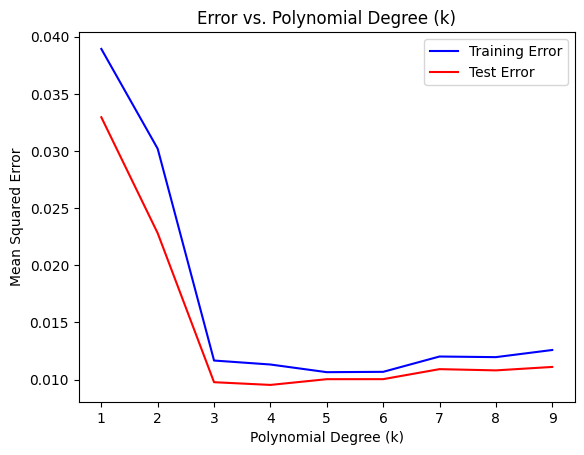

In [32]:


# Optionally, plot the error comparison with respect to the polynomial degree
k_values = np.arange(1, 10)  # Experiment with different polynomial degrees
train_errors = []
test_errors = []

for k in k_values:
    # Create polynomial features for the current degree k
    X_train_poly_k = create_polynomial_features_m(X_train_scaled, k)
    X_test_poly_k = create_polynomial_features_m(X_test_scaled, k)
    
    # Train and test the models for each k value
    theta_gd_k, _ = gradient_descent(X_train_poly_k, y_train, lr=0.01, epochs=1000)
    theta_sgd_k, _ = stochastic_gradient_descent(X_train_poly_k, y_train, lr=0.01, epochs=1000, batch_size=5)
    theta_ne_k = normal_equations_cholesky_mle(X_train_poly_k, y_train)

    # Compute errors
    train_errors.append(compute_error(X_train_poly_k, y_train, theta_gd_k))
    test_errors.append(compute_error(X_test_poly_k, y_test, theta_gd_k))

# Plot the errors
plt.plot(k_values, train_errors, label='Training Error', color='blue')
plt.plot(k_values, test_errors, label='Test Error', color='red')
plt.xlabel('Polynomial Degree (k)')
plt.ylabel('Mean Squared Error')
plt.title('Error vs. Polynomial Degree (k)')
plt.legend()
plt.show()

Polynomial Degree k=1
Error (GD): 0.03295068549517281
Error (SGD): 0.032994197412167164
Error (Normal Eq): 0.03295068546773459
------------------------------
Polynomial Degree k=2
Error (GD): 0.022806948052680225
Error (SGD): 0.02277912652307212
Error (Normal Eq): 0.022806948011826214
------------------------------
Polynomial Degree k=3
Error (GD): 0.009770245177886203
Error (SGD): 0.010610261472370899
Error (Normal Eq): 0.010592830527025336
------------------------------
Polynomial Degree k=4
Error (GD): 0.009532585339002395
Error (SGD): 0.010425236158604544
Error (Normal Eq): 0.010480367864032286
------------------------------


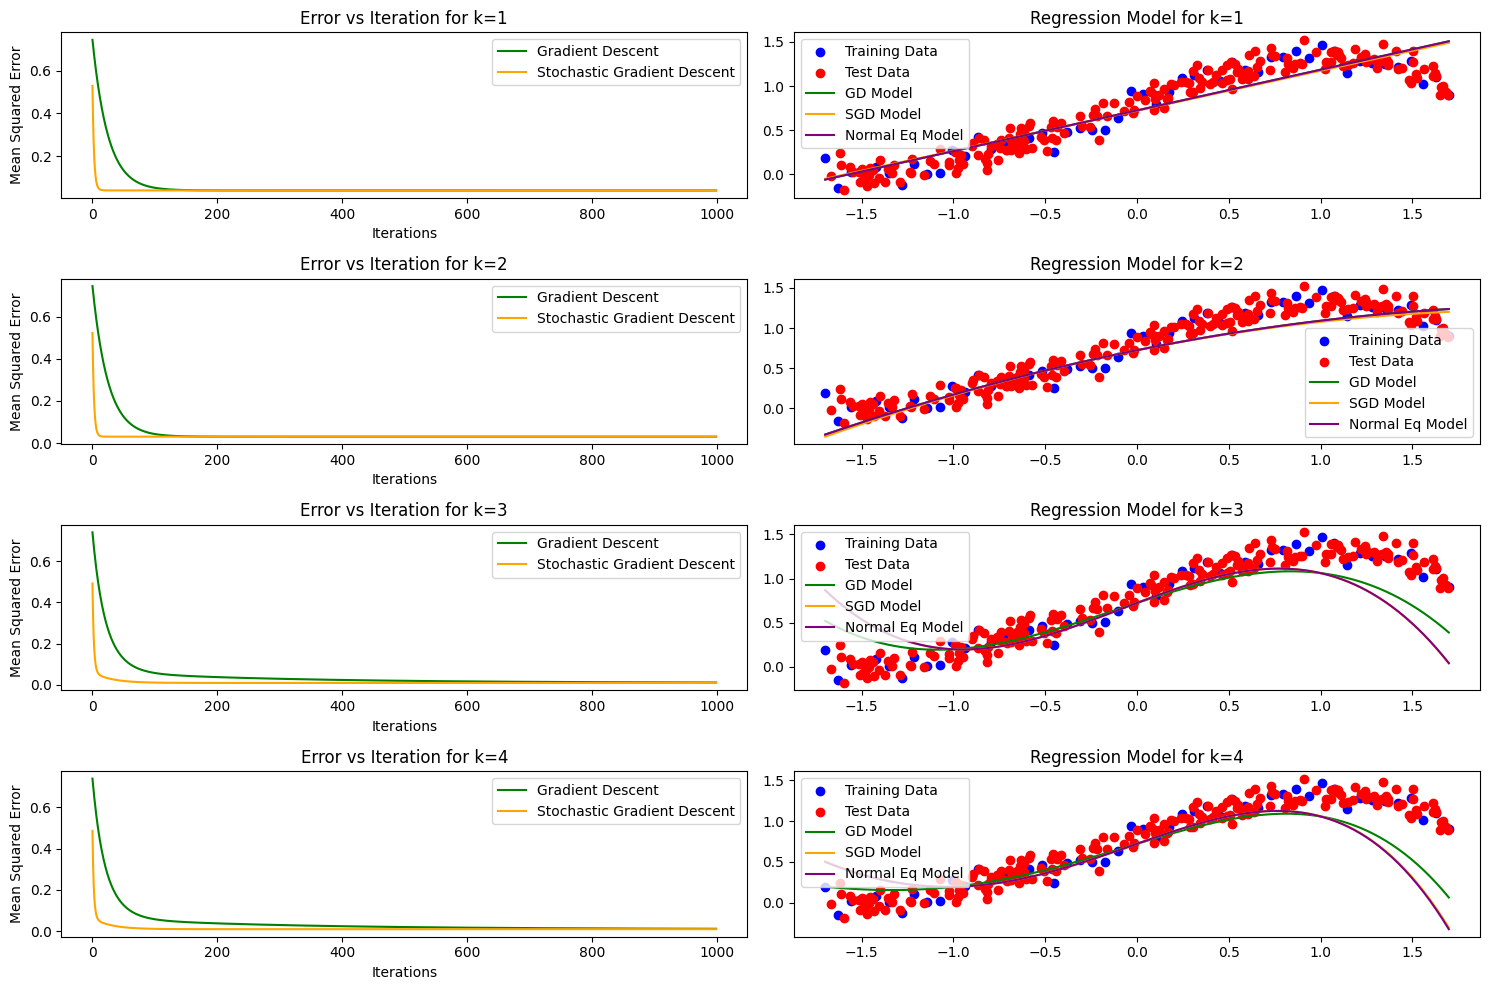

In [33]:


# Experiment with different polynomial degrees k
k_values = np.arange(1, 5)  # Experiment with different polynomial degrees
error_history_gd = []
error_history_sgd = []

# Subplots for the regression models and error comparison
fig, axs = plt.subplots(len(k_values), 2, figsize=(15, 10))

for i, k in enumerate(k_values):
    # Create polynomial features for the current degree k
    X_train_poly_k = create_polynomial_features_m(X_train_scaled, k)
    X_test_poly_k = create_polynomial_features_m(X_test_scaled, k)
    
    # Train and test the models for each k value
    theta_gd_k, error_history_gd_k = gradient_descent(X_train_poly_k, y_train, lr=0.01, epochs=1000)
    theta_sgd_k, error_history_sgd_k = stochastic_gradient_descent(X_train_poly_k, y_train, lr=0.01, epochs=1000, batch_size=5)
    theta_ne_k = normal_equations_cholesky_mle(X_train_poly_k, y_train)
        # Compute errors for each model
    error_gd = compute_error(X_test_poly_k, y_test, theta_gd_k)
    error_sgd = compute_error(X_test_poly_k, y_test, theta_sgd_k)
    error_ne = compute_error(X_test_poly_k, y_test, theta_ne_k)

    # Print errors for current degree k
    print(f"Polynomial Degree k={k}")
    print(f"Error (GD): {error_gd}")
    print(f"Error (SGD): {error_sgd}")
    print(f"Error (Normal Eq): {error_ne}")
    print("-" * 30)
    # Plot error vs iterations for both GD and SGD
    axs[i, 0].plot(error_history_gd_k, label='Gradient Descent', color='green')
    axs[i, 0].plot(error_history_sgd_k, label='Stochastic Gradient Descent', color='orange')
    axs[i, 0].set_title(f'Error vs Iteration for k={k}')
    axs[i, 0].set_xlabel('Iterations')
    axs[i, 0].set_ylabel('Mean Squared Error')
    axs[i, 0].legend()

    # Plot the regression models
    x_vals = np.linspace(X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max(), 100).reshape(-1, 1)
    x_vals_poly = create_polynomial_features(x_vals, k)

    y_vals_gd = x_vals_poly.dot(theta_gd_k)
    y_vals_sgd = x_vals_poly.dot(theta_sgd_k)
    y_vals_ne = x_vals_poly.dot(theta_ne_k)

    axs[i, 1].scatter(X_train_scaled, y_train, color='blue', label='Training Data')  # Training data
    axs[i, 1].scatter(X_test_scaled, y_test, color='red', label='Test Data')  # Test data
    axs[i, 1].plot(x_vals, y_vals_gd, label='GD Model', color='green')
    axs[i, 1].plot(x_vals, y_vals_sgd, label='SGD Model', color='orange')
    axs[i, 1].plot(x_vals, y_vals_ne, label='Normal Eq Model', color='purple')
    axs[i, 1].set_title(f'Regression Model for k={k}')
    axs[i, 1].legend()

plt.tight_layout()
plt.show()



### MAP

Polynomial Degree k=7
Error (GD)-test: 0.01100655388030459
Error (SGD)-test: 0.00979461317714204
Error (Normal Eq)-test: 0.010373080411510976
Error (GD)-train: 0.012343967400771334
Error (SGD)-train: 0.010339574144309442
Error (Normal Eq)-train: 0.008332514003132774
------------------------------
Polynomial Degree k=7
Error (GD)-test: 0.02161917023833085
Error (SGD)-test: 0.01974449699682431
Error (Normal Eq)-test: 0.009987492932374793
Error (GD)-train: 0.024057120672782054
Error (SGD)-train: 0.02245276199237598
Error (Normal Eq)-train: 0.00914773261328451
------------------------------
Polynomial Degree k=7
Error (GD)-test: 0.2132793522387969
Error (SGD)-test: 0.18910402062053727
Error (Normal Eq)-test: 0.010584908189617721
Error (GD)-train: 0.21159215122095126
Error (SGD)-train: 0.1885839906543008
Error (Normal Eq)-train: 0.011630392575149629
------------------------------
Polynomial Degree k=8
Error (GD)-test: 0.010919400751865274
Error (SGD)-test: 0.00975289454109736
Error (Normal 

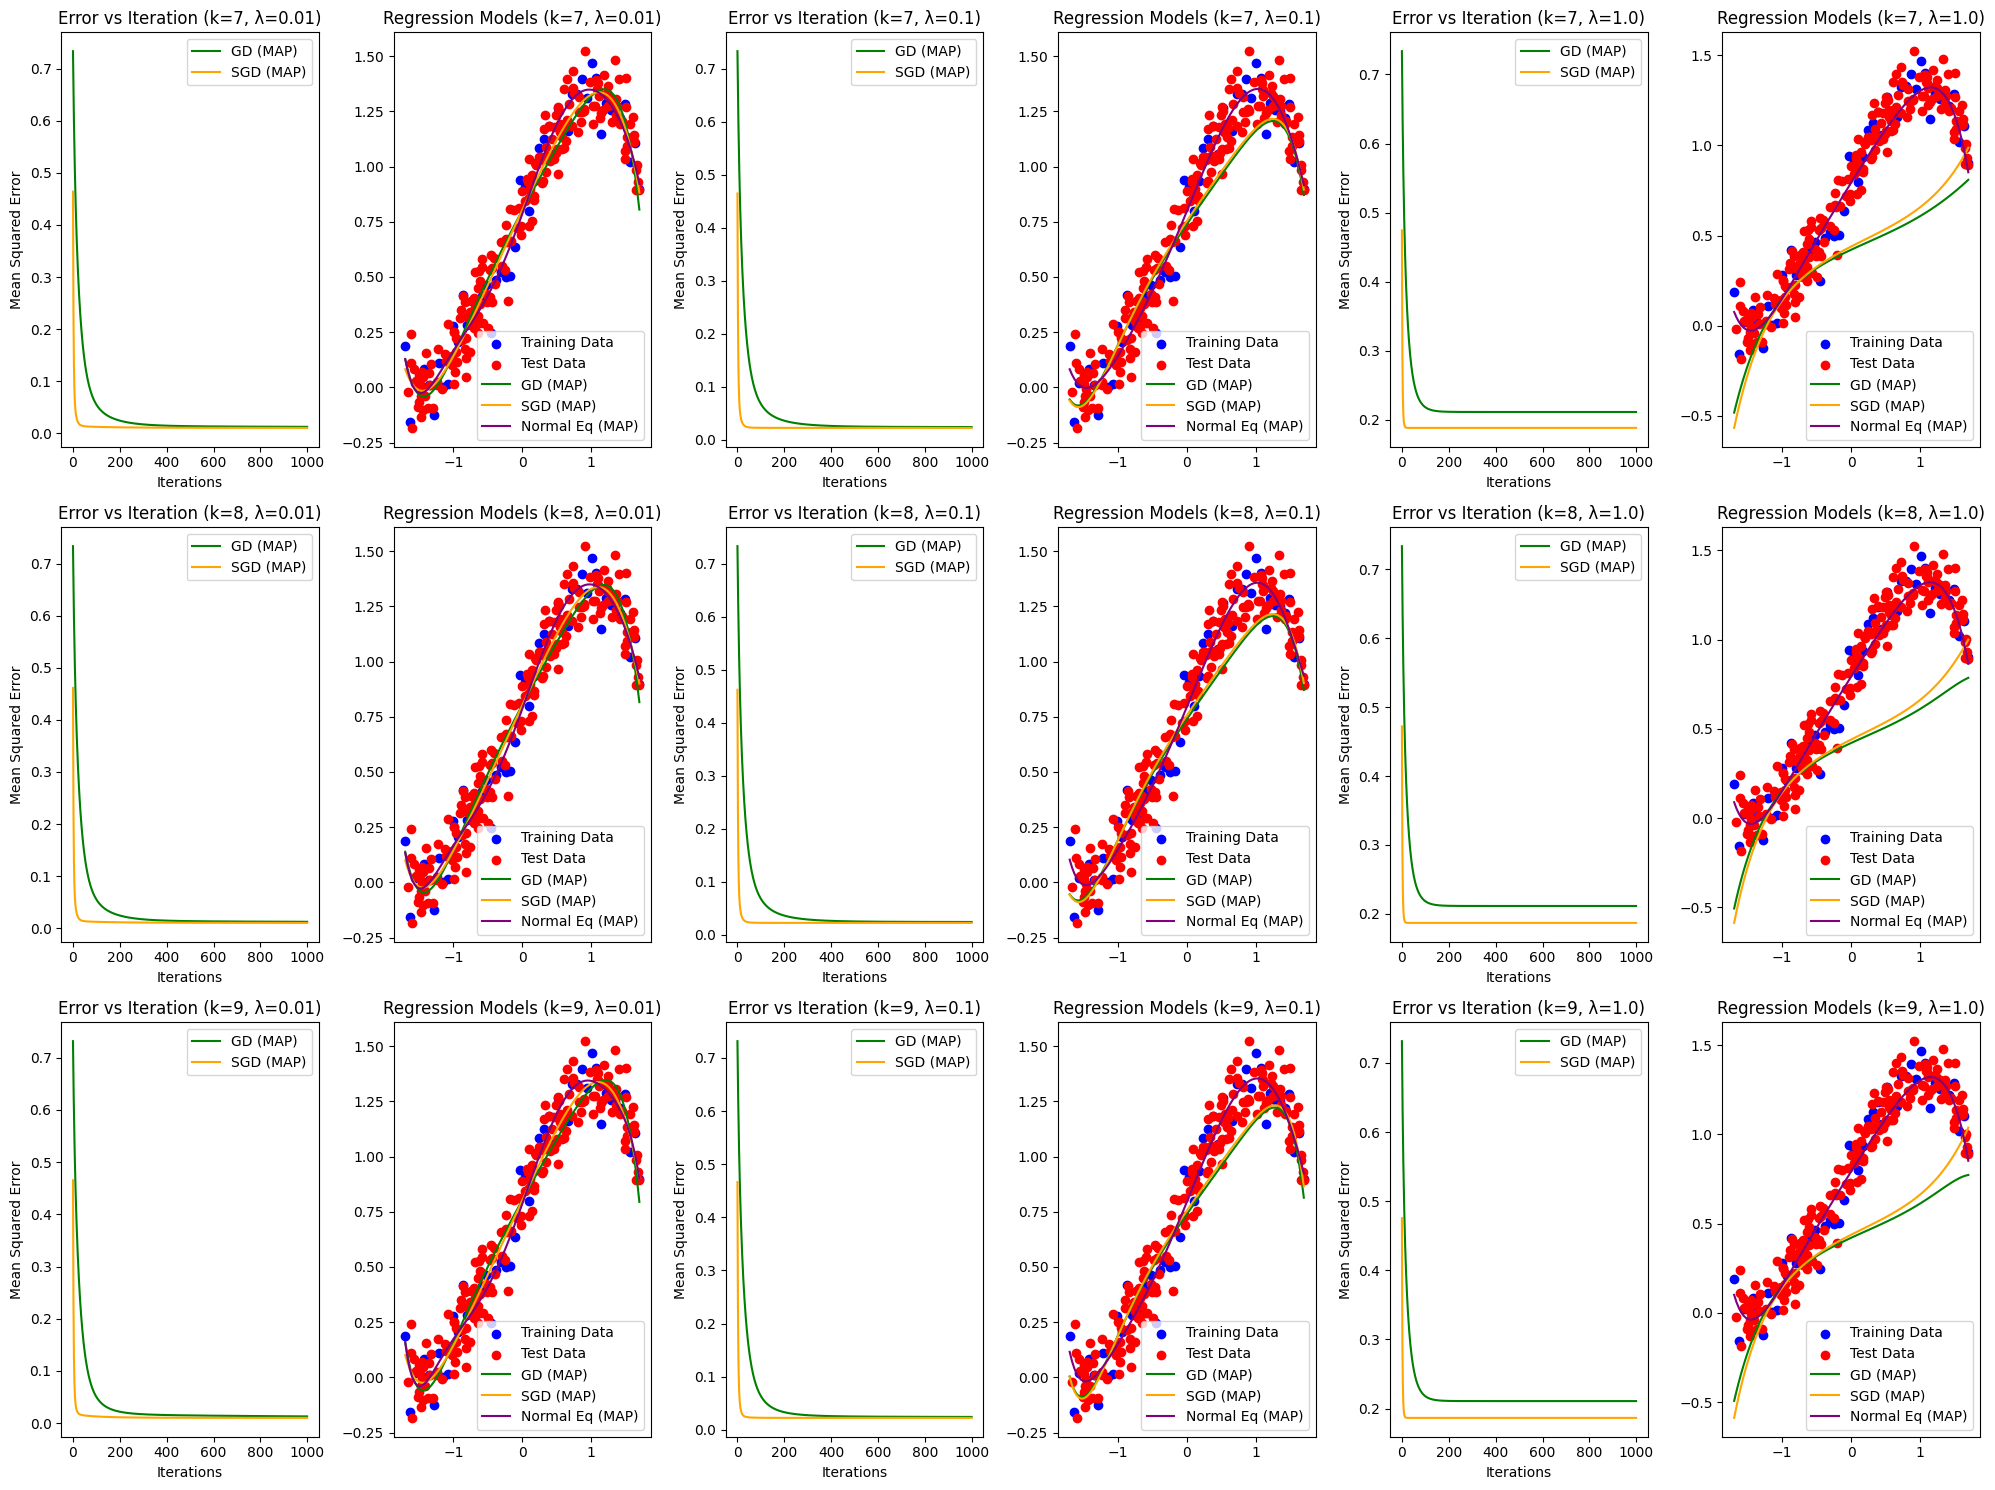

In [34]:


# Polynomial feature creation
def create_polynomial_features(X, k):
    n_samples, n_features = X.shape
    features = [np.ones(n_samples)]
    for d in range(1, k + 1):
        for comb in itertools.combinations_with_replacement(range(n_features), d):
            term = np.prod([X[:, i] ** (comb.count(i)) for i in range(n_features)], axis=0)
            features.append(term)
    poly_features = np.column_stack(features)
    # Normalize the polynomial features
    poly_features[:, 1:] = StandardScaler().fit_transform(poly_features[:, 1:])
    return poly_features

# Gradient Descent with Regularization (MAP)
def gradient_descent_map(X, y, lr=0.01, epochs=1000, lambda_reg=0.1):
    m = len(y)
    theta = np.zeros(X.shape[1])
    error_history = []
    for _ in range(epochs):
        gradients = (2/m) * X.T.dot(X.dot(theta) - y) + (2 * lambda_reg * theta)
        theta -= lr * gradients
        error_history.append(compute_error(X, y, theta))
    return theta, error_history

# Stochastic Gradient Descent with Regularization (MAP)
def stochastic_gradient_descent_map(X, y, lr=0.01, epochs=1000, batch_size=5, lambda_reg=0.1):
    m = len(y)
    theta = np.zeros(X.shape[1])
    error_history = []
    for _ in range(epochs):
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            gradients = (2/batch_size) * X_batch.T.dot(X_batch.dot(theta) - y_batch) + (2 * lambda_reg * theta)
            theta -= lr * gradients
        error_history.append(compute_error(X, y, theta))
    return theta, error_history

# Normal Equations with Regularization (MAP)
def normal_equations_cholesky_map(X, y, lambda_reg=0.1):
    X_transpose = X.T
    A = X_transpose.dot(X) + lambda_reg * np.eye(X.shape[1])
    b = X_transpose.dot(y)
    try:
        L = np.linalg.cholesky(A)
        theta = np.linalg.solve(L.T, np.linalg.solve(L, b))
    except np.linalg.LinAlgError:
        print("Cholesky decomposition failed due to non-positive definite matrix.")
        return None
    return theta

# Mean Squared Error
def compute_error(X, y, theta):
    predictions = X.dot(theta)
    return np.mean((predictions - y) ** 2)

# Experiment with different values of k and lambda
k_values = np.arange(7,10)  # Polynomial degrees
lambda_values = [0.01, 0.1, 1.0]  # Regularization parameters

# Subplots for visualizing error history and regression models
fig, axs = plt.subplots(len(k_values), len(lambda_values) * 2, figsize=(20, 15))

for i, k in enumerate(k_values):
    for j, lambda_reg in enumerate(lambda_values):
        # Create polynomial features
        X_train_poly_k = create_polynomial_features(X_train_scaled, k)
        X_test_poly_k = create_polynomial_features(X_test_scaled, k)

        # Train models
        theta_gd_map_k, error_history_gd = gradient_descent_map(X_train_poly_k, y_train, lr=0.01, epochs=1000, lambda_reg=lambda_reg)
        theta_sgd_map_k, error_history_sgd = stochastic_gradient_descent_map(X_train_poly_k, y_train, lr=0.01, epochs=1000, batch_size=5, lambda_reg=lambda_reg)
        theta_ne_map_k = normal_equations_cholesky_map(X_train_poly_k, y_train, lambda_reg=lambda_reg)
        error_gd = compute_error(X_test_poly_k, y_test, theta_gd_map_k)
        error_sgd = compute_error(X_test_poly_k, y_test, theta_sgd_map_k)
        error_ne = compute_error(X_test_poly_k, y_test, theta_ne_map_k)
        err_gd_tr=(compute_error(X_train_poly_k, y_train, theta_gd_map_k))
        err_sgd_tr=(compute_error(X_train_poly_k, y_train, theta_sgd_map_k))
        err_ne_tr=(compute_error(X_train_poly_k, y_train, theta_ne_map_k))

        # Print errors for current degree k
        print(f"Polynomial Degree k={k}")
        print(f"Error (GD)-test: {error_gd}")
        print(f"Error (SGD)-test: {error_sgd}")
        print(f"Error (Normal Eq)-test: {error_ne}")
        print(f"Error (GD)-train: {err_gd_tr}")
        print(f"Error (SGD)-train: {err_sgd_tr}")
        print(f"Error (Normal Eq)-train: {err_ne_tr}")
        print("-" * 30)
        
        # Plot Error vs Iteration
        axs[i, j * 2].plot(error_history_gd, label='GD (MAP)', color='green')
        axs[i, j * 2].plot(error_history_sgd, label='SGD (MAP)', color='orange')
        axs[i, j * 2].set_title(f'Error vs Iteration (k={k}, λ={lambda_reg})')
        axs[i, j * 2].set_xlabel('Iterations')
        axs[i, j * 2].set_ylabel('Mean Squared Error')
        axs[i, j * 2].legend()

        # Plot Regression Models
        x_vals = np.linspace(X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max(), 100).reshape(-1, 1)
        x_vals_poly = create_polynomial_features(x_vals, k)

        y_vals_gd_map = x_vals_poly.dot(theta_gd_map_k)
        y_vals_sgd_map = x_vals_poly.dot(theta_sgd_map_k)
        y_vals_ne_map = x_vals_poly.dot(theta_ne_map_k)

        axs[i, j * 2 + 1].scatter(X_train_scaled, y_train, color='blue', label='Training Data')
        axs[i, j * 2 + 1].scatter(X_test_scaled, y_test, color='red', label='Test Data')
        axs[i, j * 2 + 1].plot(x_vals, y_vals_gd_map, label='GD (MAP)', color='green')
        axs[i, j * 2 + 1].plot(x_vals, y_vals_sgd_map, label='SGD (MAP)', color='orange')
        axs[i, j * 2 + 1].plot(x_vals, y_vals_ne_map, label='Normal Eq (MAP)', color='purple')
        axs[i, j * 2 + 1].set_title(f'Regression Models (k={k}, λ={lambda_reg})')
        axs[i, j * 2 + 1].legend()

plt.tight_layout()
plt.show()

Polynomial Degree k=7
Error (GD)-test: 0.01100655388030459
Error (SGD)-test: 0.00979461317714204
Error (Normal Eq)-test: 0.010373080411510976
Error (GD)-train: 0.012343967400771334
Error (SGD)-train: 0.010339574144309442
Error (Normal Eq)-train: 0.008332514003132774
------------------------------


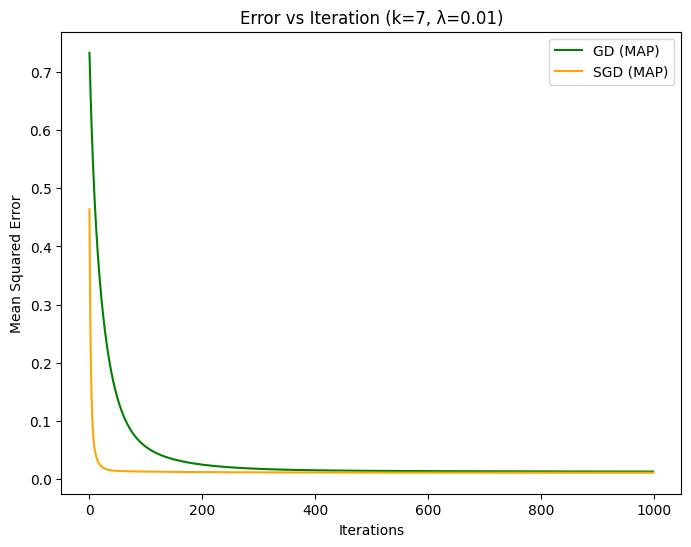

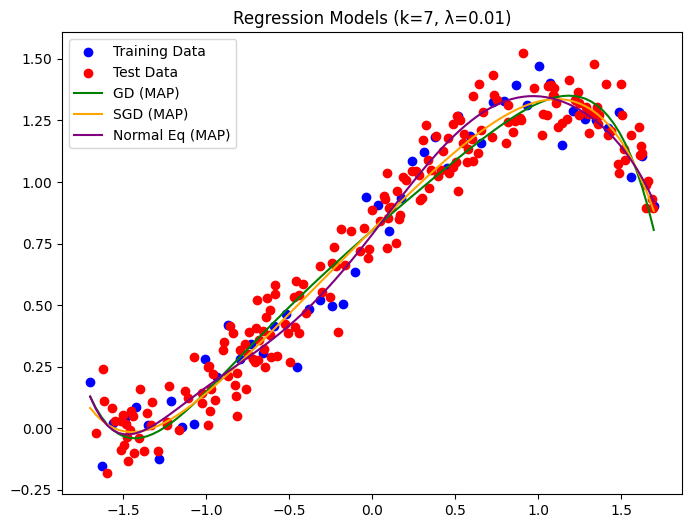

Polynomial Degree k=7
Error (GD)-test: 0.02161917023833085
Error (SGD)-test: 0.01974449699682431
Error (Normal Eq)-test: 0.009987492932374793
Error (GD)-train: 0.024057120672782054
Error (SGD)-train: 0.02245276199237598
Error (Normal Eq)-train: 0.00914773261328451
------------------------------


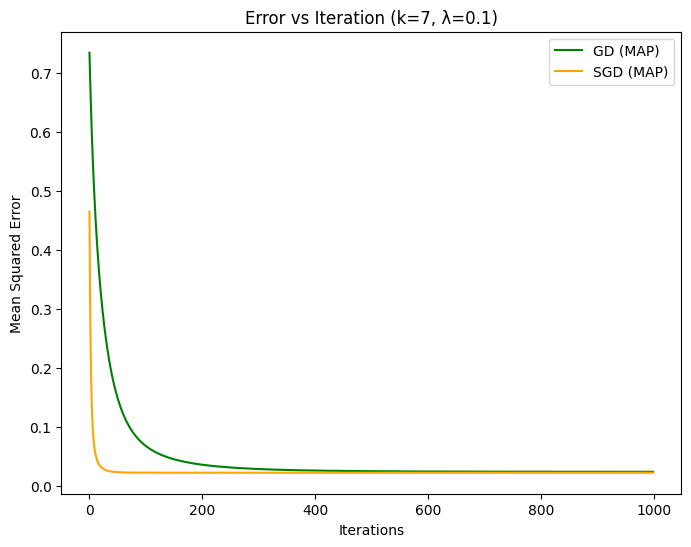

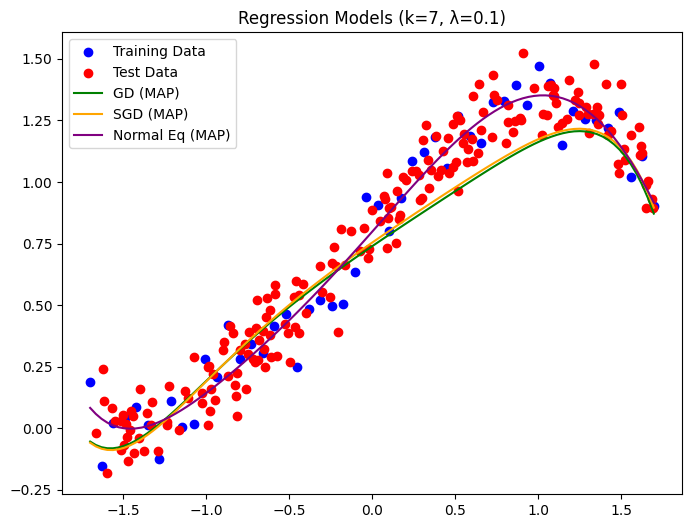

Polynomial Degree k=7
Error (GD)-test: 0.2132793522387969
Error (SGD)-test: 0.18910402062053727
Error (Normal Eq)-test: 0.010584908189617721
Error (GD)-train: 0.21159215122095126
Error (SGD)-train: 0.1885839906543008
Error (Normal Eq)-train: 0.011630392575149629
------------------------------


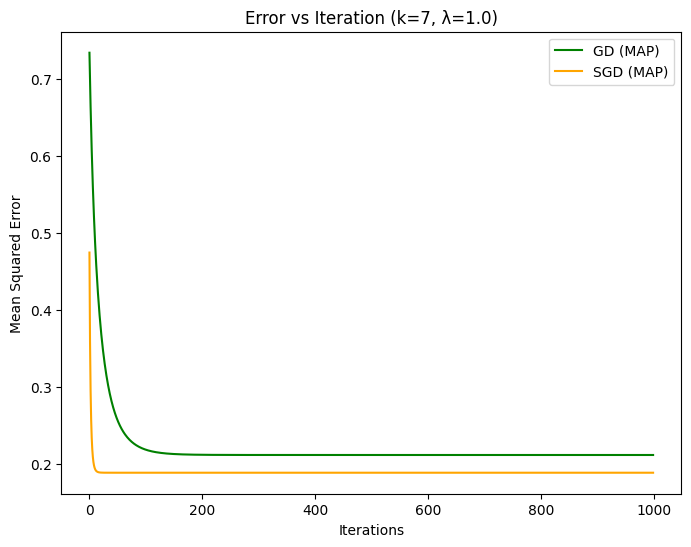

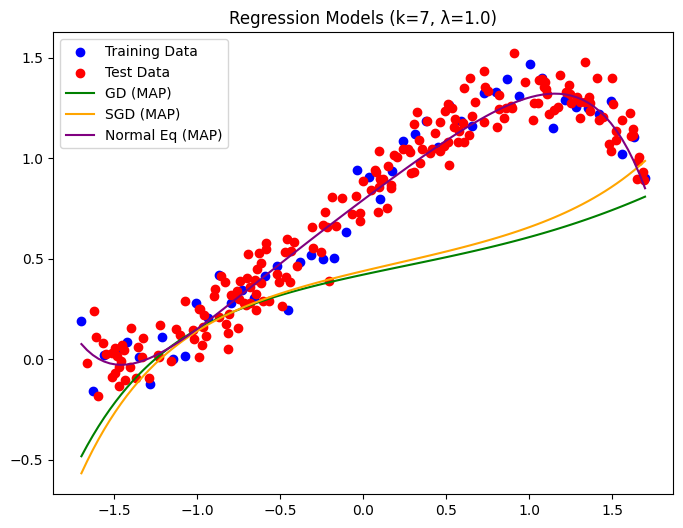

Polynomial Degree k=8
Error (GD)-test: 0.010919400751865274
Error (SGD)-test: 0.00975289454109736
Error (Normal Eq)-test: 0.010390600391111837
Error (GD)-train: 0.012294578808747549
Error (SGD)-train: 0.010214650930211655
Error (Normal Eq)-train: 0.008343765171066959
------------------------------


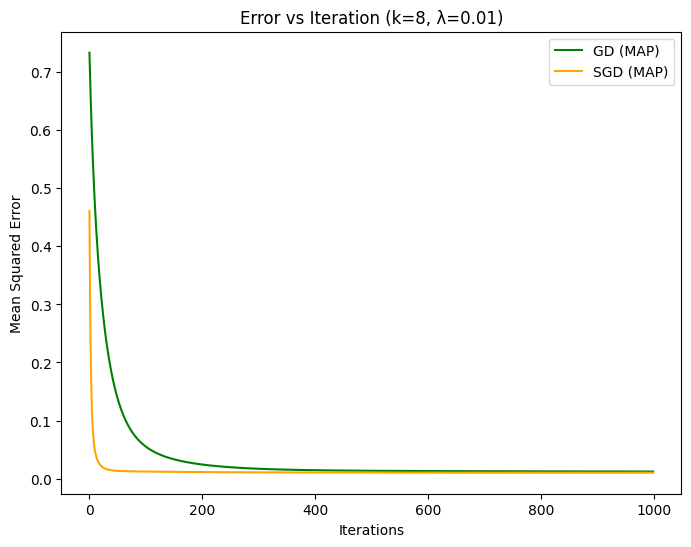

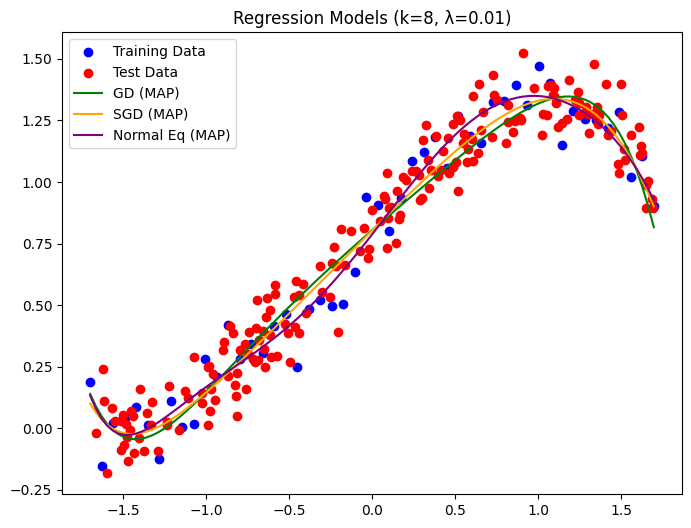

Polynomial Degree k=8
Error (GD)-test: 0.021615762212457996
Error (SGD)-test: 0.019575058905105004
Error (Normal Eq)-test: 0.01004349281772654
Error (GD)-train: 0.02405641120153282
Error (SGD)-train: 0.022330534109964013
Error (Normal Eq)-train: 0.009082705152806935
------------------------------


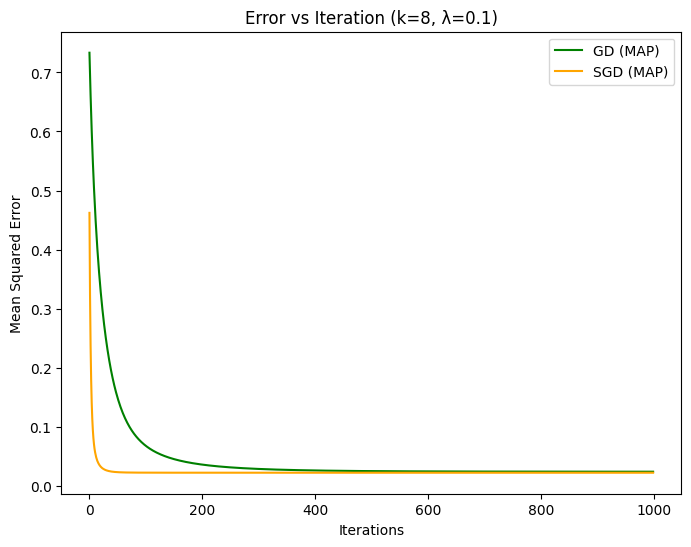

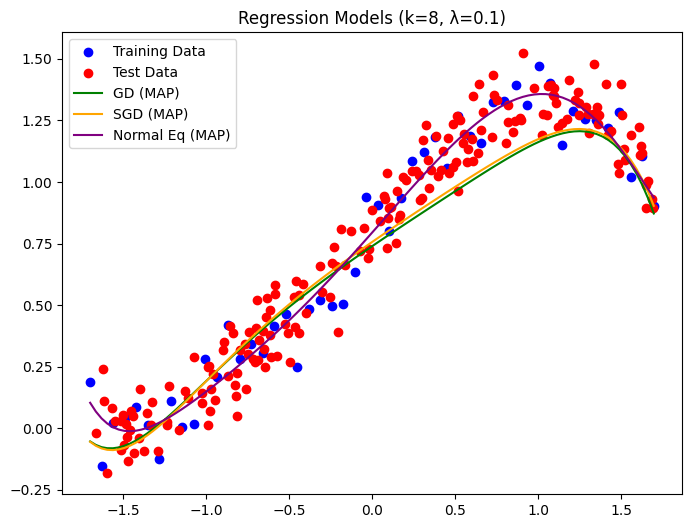

Polynomial Degree k=8
Error (GD)-test: 0.21305723752569516
Error (SGD)-test: 0.18722275539222633
Error (Normal Eq)-test: 0.010538047661902791
Error (GD)-train: 0.2115689422020526
Error (SGD)-train: 0.18705896340670713
Error (Normal Eq)-train: 0.011537034808540068
------------------------------


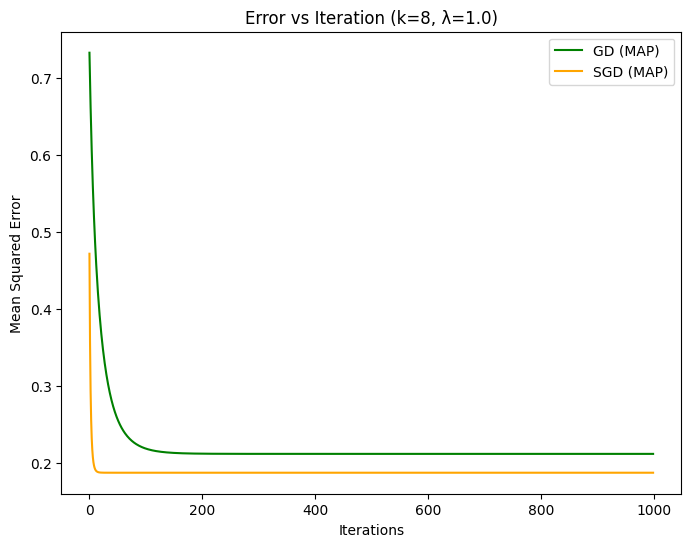

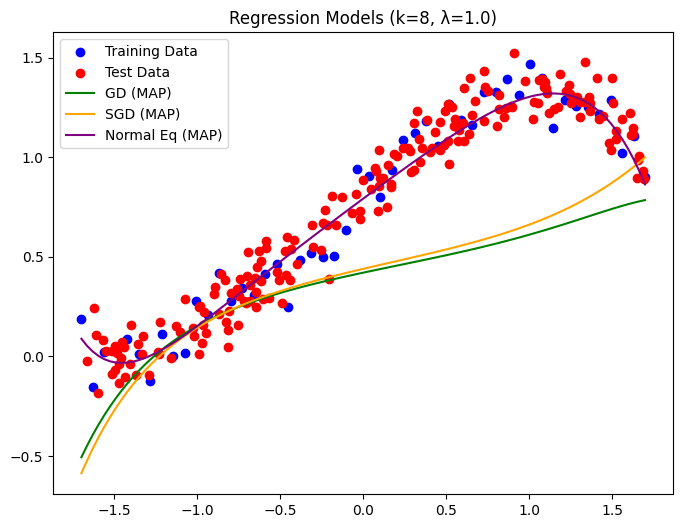

Polynomial Degree k=9
Error (GD)-test: 0.011435521001430122
Error (SGD)-test: 0.009739174259409168
Error (Normal Eq)-test: 0.010477989556525185
Error (GD)-train: 0.013057243671912739
Error (SGD)-train: 0.010220024373652664
Error (Normal Eq)-train: 0.008265477066823878
------------------------------


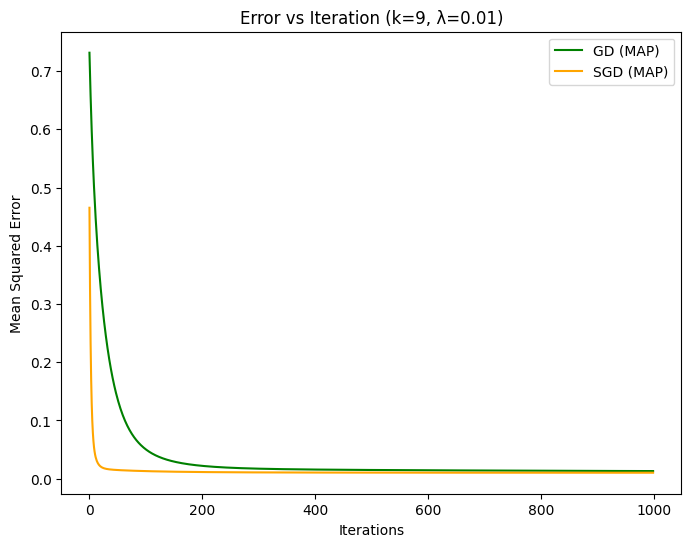

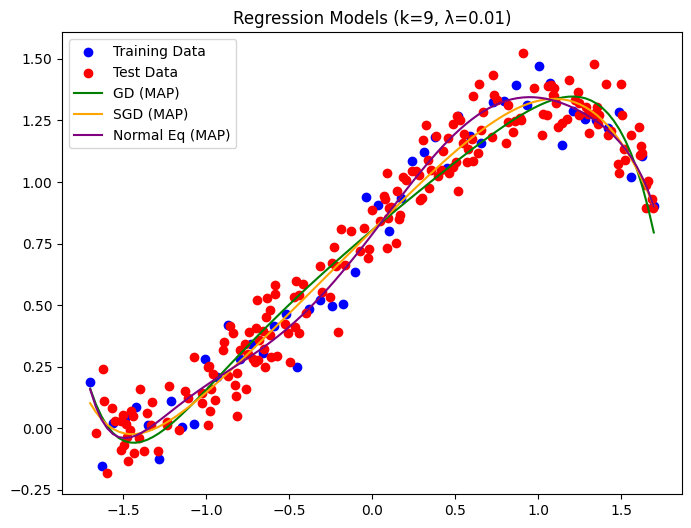

Polynomial Degree k=9
Error (GD)-test: 0.021914736282642545
Error (SGD)-test: 0.01965083963138249
Error (Normal Eq)-test: 0.0099805349858431
Error (GD)-train: 0.024102843926376655
Error (SGD)-train: 0.022311747421128177
Error (Normal Eq)-train: 0.008968551832384127
------------------------------


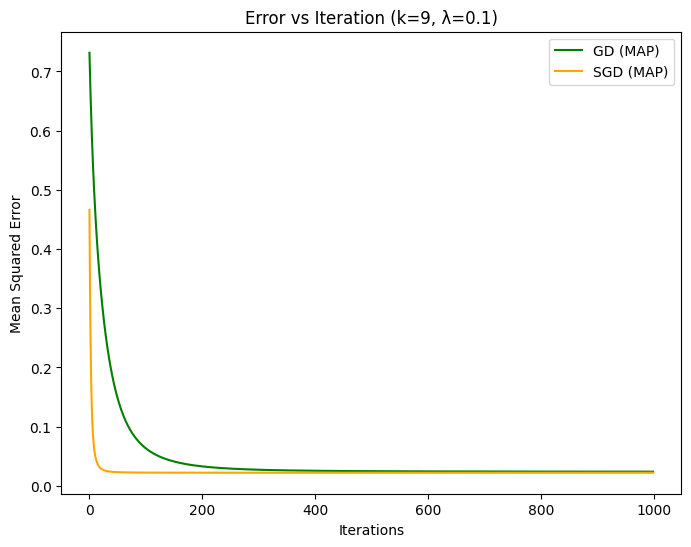

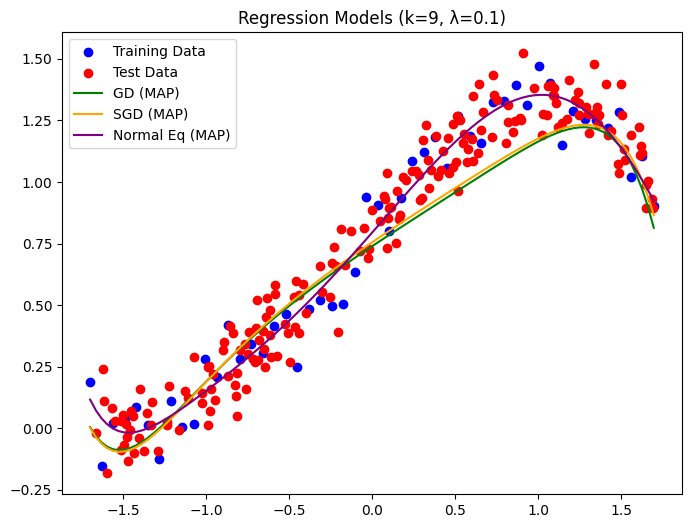

Polynomial Degree k=9
Error (GD)-test: 0.21250723995259996
Error (SGD)-test: 0.1867653811157452
Error (Normal Eq)-test: 0.010630201367851064
Error (GD)-train: 0.21090048058922609
Error (SGD)-train: 0.18660224573824943
Error (Normal Eq)-train: 0.011632775915842076
------------------------------


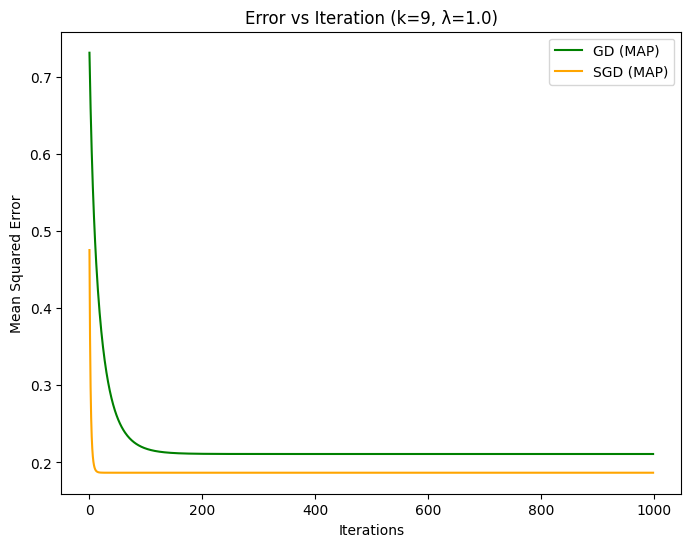

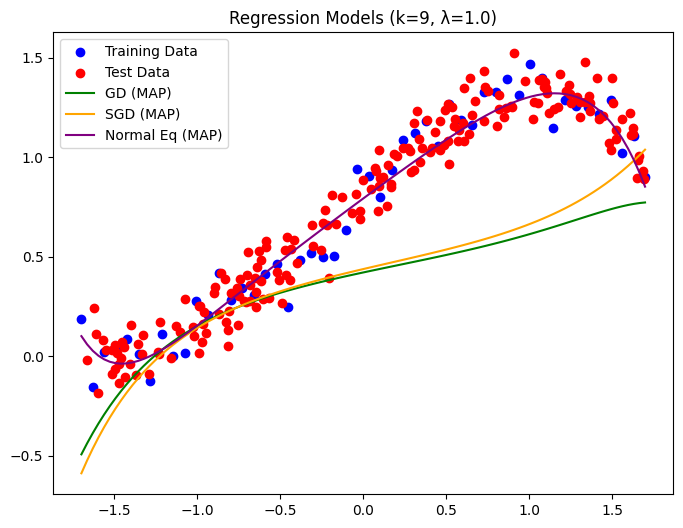

In [35]:
# Experiment with different values of k and lambda
k_values = np.arange(7, 10)  # Polynomial degrees
lambda_values = [0.01, 0.1, 1.0]  # Regularization parameters

for i, k in enumerate(k_values):
    for j, lambda_reg in enumerate(lambda_values):
        # Create polynomial features
        X_train_poly_k = create_polynomial_features(X_train_scaled, k)
        X_test_poly_k = create_polynomial_features(X_test_scaled, k)

        # Train models
        theta_gd_map_k, error_history_gd = gradient_descent_map(X_train_poly_k, y_train, lr=0.01, epochs=1000, lambda_reg=lambda_reg)
        theta_sgd_map_k, error_history_sgd = stochastic_gradient_descent_map(X_train_poly_k, y_train, lr=0.01, epochs=1000, batch_size=5, lambda_reg=lambda_reg)
        theta_ne_map_k = normal_equations_cholesky_map(X_train_poly_k, y_train, lambda_reg=lambda_reg)
        error_gd = compute_error(X_test_poly_k, y_test, theta_gd_map_k)
        error_sgd = compute_error(X_test_poly_k, y_test, theta_sgd_map_k)
        error_ne = compute_error(X_test_poly_k, y_test, theta_ne_map_k)
        err_gd_tr=(compute_error(X_train_poly_k, y_train, theta_gd_map_k))
        err_sgd_tr=(compute_error(X_train_poly_k, y_train, theta_sgd_map_k))
        err_ne_tr=(compute_error(X_train_poly_k, y_train, theta_ne_map_k))

        # Print errors for current degree k
        print(f"Polynomial Degree k={k}")
        print(f"Error (GD)-test: {error_gd}")
        print(f"Error (SGD)-test: {error_sgd}")
        print(f"Error (Normal Eq)-test: {error_ne}")
        print(f"Error (GD)-train: {err_gd_tr}")
        print(f"Error (SGD)-train: {err_sgd_tr}")
        print(f"Error (Normal Eq)-train: {err_ne_tr}")
        print("-" * 30)
        # Plot Error vs Iteration
        plt.figure(figsize=(8, 6))
        plt.plot(error_history_gd, label='GD (MAP)', color='green')
        plt.plot(error_history_sgd, label='SGD (MAP)', color='orange')
        plt.title(f'Error vs Iteration (k={k}, λ={lambda_reg})')
        plt.xlabel('Iterations')
        plt.ylabel('Mean Squared Error')
        plt.legend()
        plt.show()

        # Plot Regression Models
        x_vals = np.linspace(X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max(), 100).reshape(-1, 1)
        x_vals_poly = create_polynomial_features(x_vals, k)

        y_vals_gd_map = x_vals_poly.dot(theta_gd_map_k)
        y_vals_sgd_map = x_vals_poly.dot(theta_sgd_map_k)
        y_vals_ne_map = x_vals_poly.dot(theta_ne_map_k)

        plt.figure(figsize=(8, 6))
        plt.scatter(X_train_scaled, y_train, color='blue', label='Training Data')
        plt.scatter(X_test_scaled, y_test, color='red', label='Test Data')
        plt.plot(x_vals, y_vals_gd_map, label='GD (MAP)', color='green')
        plt.plot(x_vals, y_vals_sgd_map, label='SGD (MAP)', color='orange')
        plt.plot(x_vals, y_vals_ne_map, label='Normal Eq (MAP)', color='purple')
        plt.title(f'Regression Models (k={k}, λ={lambda_reg})')
        plt.legend()
        plt.show()
        

## only for k=8

Polynomial Degree k=8
Error (GD): 0.010804673776508204
Error (SGD): 0.01018384852486668
Error (Normal Eq): 0.010907625425729478
------------------------------


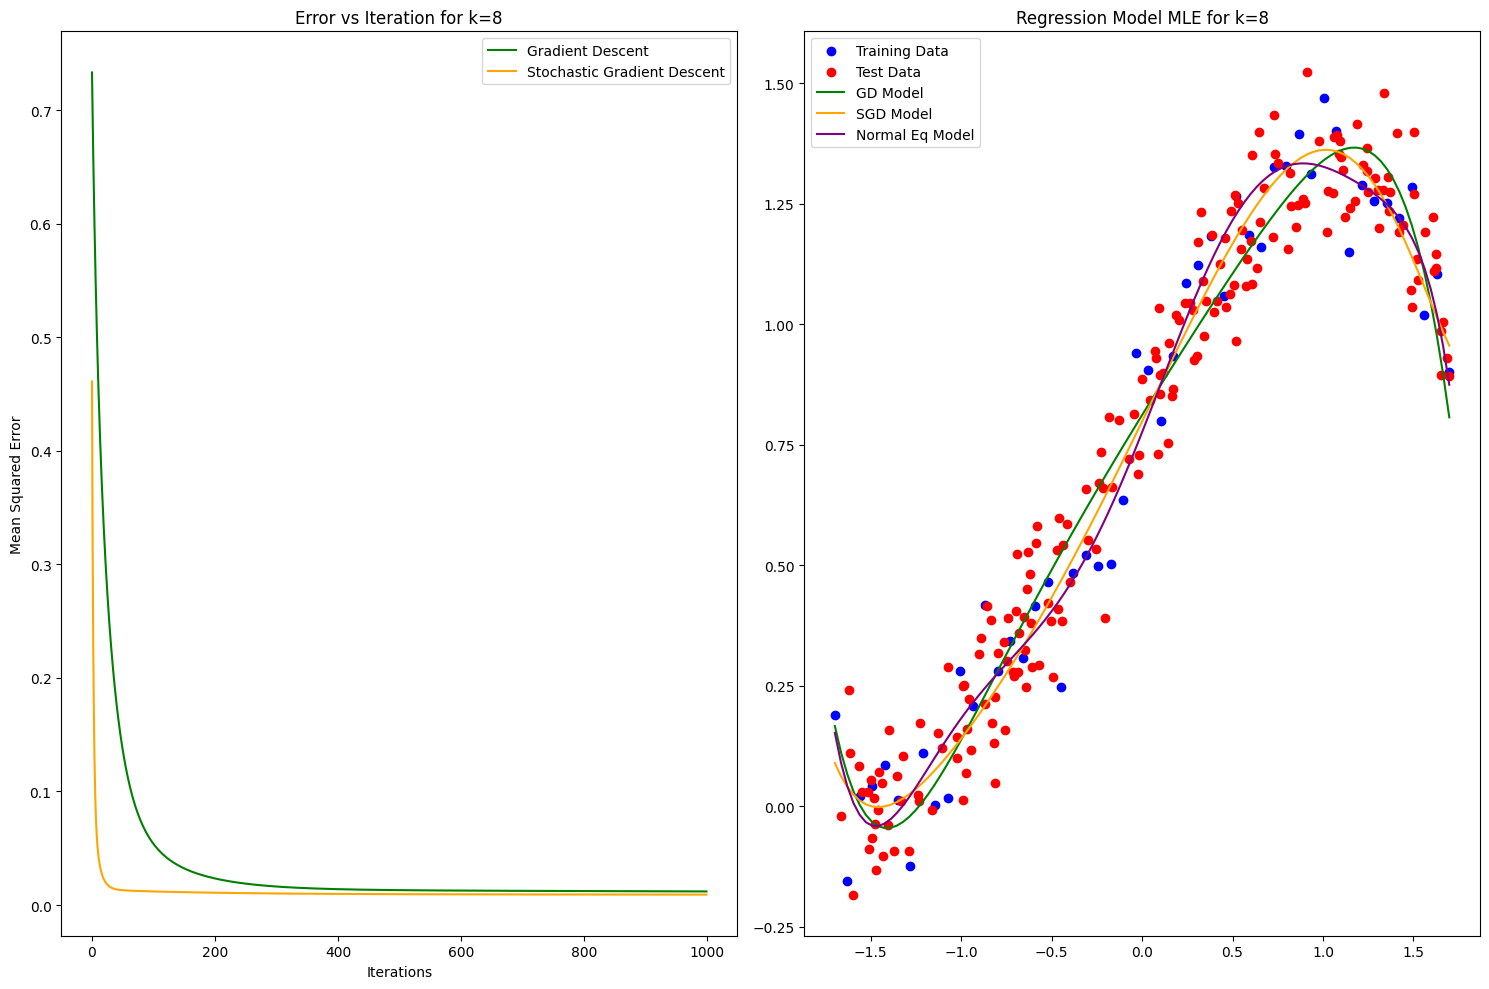

In [36]:
# Experiment with polynomial degree k = 8
k = 8  # Fixed degree

error_history_gd = []
error_history_sgd = []

# Subplots for the regression models and error comparison
fig, axs = plt.subplots(1, 2, figsize=(15, 10))

# Create polynomial features for the degree k
X_train_poly_k = create_polynomial_features(X_train_scaled, k)
X_test_poly_k = create_polynomial_features(X_test_scaled, k)

# Train and test the models for k = 8
theta_gd_k, error_history_gd_k = gradient_descent(X_train_poly_k, y_train, lr=0.01, epochs=1000)
theta_sgd_k, error_history_sgd_k = stochastic_gradient_descent(X_train_poly_k, y_train, lr=0.01, epochs=1000, batch_size=5)
theta_ne_k = normal_equations_cholesky_mle(X_train_poly_k, y_train)

# Compute errors for each model
error_gd = compute_error(X_test_poly_k, y_test, theta_gd_k)
error_sgd = compute_error(X_test_poly_k, y_test, theta_sgd_k)
error_ne = compute_error(X_test_poly_k, y_test, theta_ne_k)

# Print errors for k = 8
print(f"Polynomial Degree k={k}")
print(f"Error (GD): {error_gd}")
print(f"Error (SGD): {error_sgd}")
print(f"Error (Normal Eq): {error_ne}")
print("-" * 30)

# Plot error vs iterations for both GD and SGD
axs[0].plot(error_history_gd_k, label='Gradient Descent', color='green')
axs[0].plot(error_history_sgd_k, label='Stochastic Gradient Descent', color='orange')
axs[0].set_title(f'Error vs Iteration for k={k}')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Mean Squared Error')
axs[0].legend()

# Plot the regression models
x_vals = np.linspace(X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max(), 100).reshape(-1, 1)
x_vals_poly = create_polynomial_features(x_vals, k)

y_vals_gd = x_vals_poly.dot(theta_gd_k)
y_vals_sgd = x_vals_poly.dot(theta_sgd_k)
y_vals_ne = x_vals_poly.dot(theta_ne_k)

axs[1].scatter(X_train_scaled, y_train, color='blue', label='Training Data')  # Training data
axs[1].scatter(X_test_scaled, y_test, color='red', label='Test Data')  # Test data
axs[1].plot(x_vals, y_vals_gd, label='GD Model', color='green')
axs[1].plot(x_vals, y_vals_sgd, label='SGD Model', color='orange')
axs[1].plot(x_vals, y_vals_ne, label='Normal Eq Model', color='purple')
axs[1].set_title(f'Regression Model MLE for k={k}')
axs[1].legend()

plt.tight_layout()
plt.show()

Polynomial Degree k=8
Error (GD): 0.010804673776508204
Error (SGD): 0.01018384852486668
Error (Normal Eq): 0.010907625425729478
------------------------------


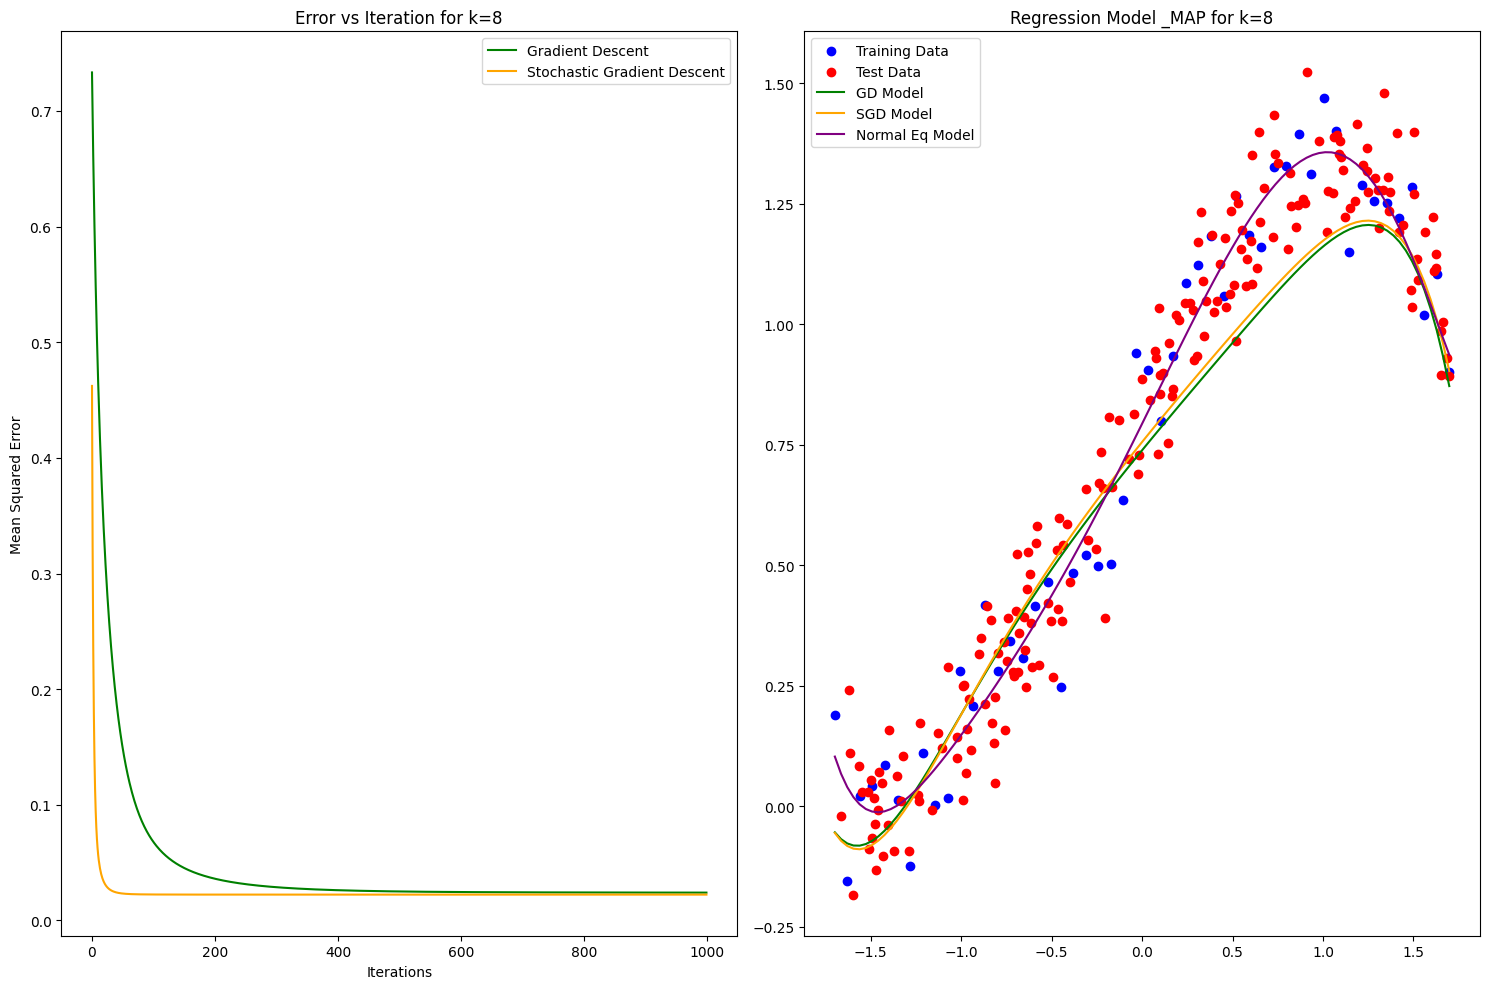

In [37]:
# Experiment with polynomial degree k = 8
k = 8  # Fixed degree

error_history_gd = []
error_history_sgd = []

# Subplots for the regression models and error comparison
fig, axs = plt.subplots(1, 2, figsize=(15, 10))

# Create polynomial features for the degree k
X_train_poly_k = create_polynomial_features(X_train_scaled, k)
X_test_poly_k = create_polynomial_features(X_test_scaled, k)

# Train and test the models for k = 8
theta_gd_k, error_history_gd_k = gradient_descent_map(X_train_poly_k, y_train, lr=0.01, epochs=1000)
theta_sgd_k, error_history_sgd_k = stochastic_gradient_descent_map(X_train_poly_k, y_train, lr=0.01, epochs=1000, batch_size=5)
theta_ne_k = normal_equations_cholesky_map(X_train_poly_k, y_train)


# Print errors for k = 8
print(f"Polynomial Degree k={k}")
print(f"Error (GD): {error_gd}")
print(f"Error (SGD): {error_sgd}")
print(f"Error (Normal Eq): {error_ne}")
print("-" * 30)

# Plot error vs iterations for both GD and SGD
axs[0].plot(error_history_gd_k, label='Gradient Descent', color='green')
axs[0].plot(error_history_sgd_k, label='Stochastic Gradient Descent', color='orange')
axs[0].set_title(f'Error vs Iteration for k={k}')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Mean Squared Error')
axs[0].legend()

# Plot the regression models
x_vals = np.linspace(X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max(), 100).reshape(-1, 1)
x_vals_poly = create_polynomial_features(x_vals, k)

y_vals_gd = x_vals_poly.dot(theta_gd_k)
y_vals_sgd = x_vals_poly.dot(theta_sgd_k)
y_vals_ne = x_vals_poly.dot(theta_ne_k)

axs[1].scatter(X_train_scaled, y_train, color='blue', label='Training Data')  # Training data
axs[1].scatter(X_test_scaled, y_test, color='red', label='Test Data')  # Test data
axs[1].plot(x_vals, y_vals_gd, label='GD Model', color='green')
axs[1].plot(x_vals, y_vals_sgd, label='SGD Model', color='orange')
axs[1].plot(x_vals, y_vals_ne, label='Normal Eq Model', color='purple')
axs[1].set_title(f'Regression Model _MAP for k={k}')
axs[1].legend()

plt.tight_layout()
plt.show()

Polynomial Degree k=8 , λ(for MAP)=0.01
Error (GD MLE): 0.010804673776508204
Error (SGD MLE): 0.01018384852486668
Error (Normal Eq MLE): 0.010907625425729478
Error (GD MAP): 0.010919400751865274
Error (SGD MAP): 0.00975289454109736
Error (Normal Eq MAP): 0.010390600391111837
------------------------------


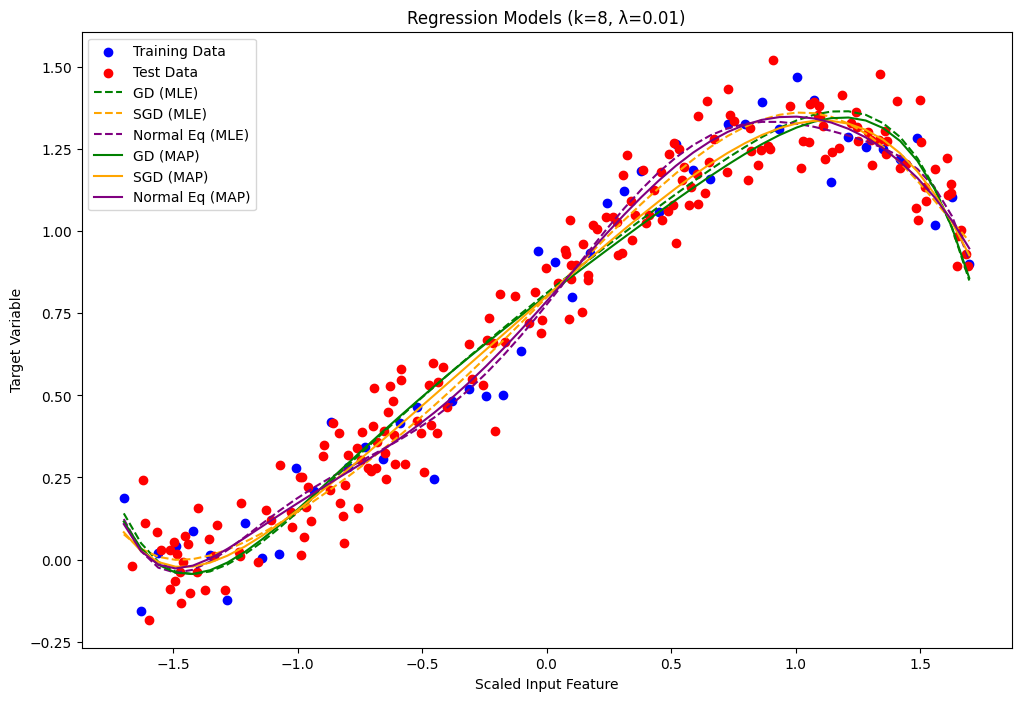

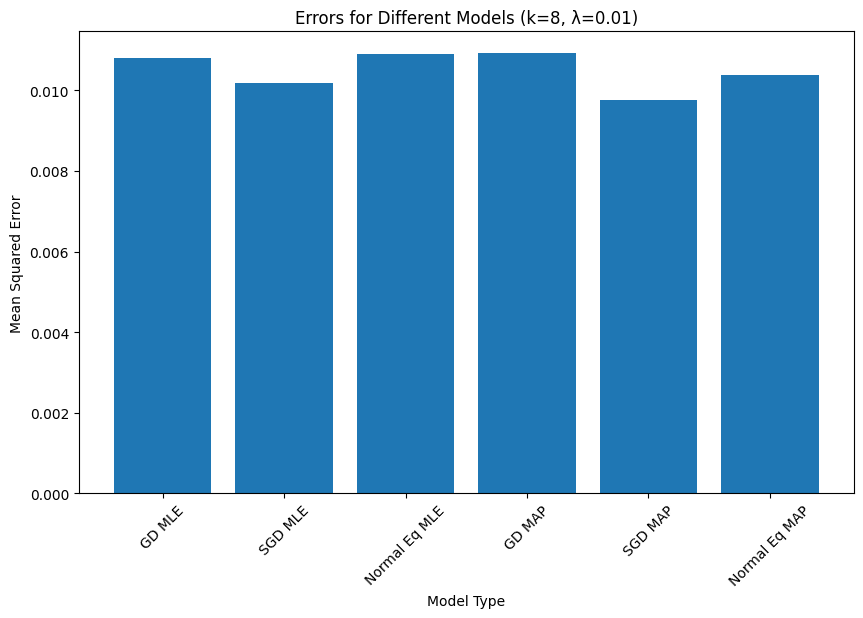

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Set polynomial degree and regularization parameter
k = 8
lambda_reg = 0.01

# Create polynomial features
X_train_poly = create_polynomial_features_m(X_train_scaled, k)
X_test_poly = create_polynomial_features_m(X_test_scaled, k)

# Train MLE models
theta_gd_mle, _ = gradient_descent(X_train_poly, y_train, lr=0.01, epochs=1000)
theta_sgd_mle, _ = stochastic_gradient_descent(X_train_poly, y_train, lr=0.01, epochs=1000, batch_size=5)
theta_ne_mle = normal_equations_cholesky_mle(X_train_poly, y_train)

# Train MAP models
theta_gd_map, _ = gradient_descent_map(X_train_poly, y_train, lr=0.01, epochs=1000, lambda_reg=lambda_reg)
theta_sgd_map, _ = stochastic_gradient_descent_map(X_train_poly, y_train, lr=0.01, epochs=1000, batch_size=5, lambda_reg=lambda_reg)
theta_ne_map = normal_equations_cholesky_map(X_train_poly, y_train, lambda_reg=lambda_reg)

# Compute predictions for training and test data
y_train_gd_mle = X_train_poly.dot(theta_gd_mle)
y_train_sgd_mle = X_train_poly.dot(theta_sgd_mle)
y_train_ne_mle = X_train_poly.dot(theta_ne_mle)
y_train_gd_map = X_train_poly.dot(theta_gd_map)
y_train_sgd_map = X_train_poly.dot(theta_sgd_map)
y_train_ne_map = X_train_poly.dot(theta_ne_map)

y_test_gd_mle = X_test_poly.dot(theta_gd_mle)
y_test_sgd_mle = X_test_poly.dot(theta_sgd_mle)
y_test_ne_mle = X_test_poly.dot(theta_ne_mle)
y_test_gd_map = X_test_poly.dot(theta_gd_map)
y_test_sgd_map = X_test_poly.dot(theta_sgd_map)
y_test_ne_map = X_test_poly.dot(theta_ne_map)

# Compute errors (Mean Squared Error)
def compute_error(X_poly, y, theta):
    predictions = X_poly.dot(theta)
    return np.mean((predictions - y) ** 2)

error_gd_mle = compute_error(X_test_poly, y_test, theta_gd_mle)
error_sgd_mle = compute_error(X_test_poly, y_test, theta_sgd_mle)
error_ne_mle = compute_error(X_test_poly, y_test, theta_ne_mle)

error_gd_map = compute_error(X_test_poly, y_test, theta_gd_map)
error_sgd_map = compute_error(X_test_poly, y_test, theta_sgd_map)
error_ne_map = compute_error(X_test_poly, y_test, theta_ne_map)

# Print errors for current degree k
print(f"Polynomial Degree k={k} , λ(for MAP)={lambda_reg}")
print(f"Error (GD MLE): {error_gd_mle}")
print(f"Error (SGD MLE): {error_sgd_mle}")
print(f"Error (Normal Eq MLE): {error_ne_mle}")
print(f"Error (GD MAP): {error_gd_map}")
print(f"Error (SGD MAP): {error_sgd_map}")
print(f"Error (Normal Eq MAP): {error_ne_map}")
print("-" * 30)

# Plot the models
plt.figure(figsize=(12, 8))

# Scatter training data
plt.scatter(X_train_scaled, y_train, color='blue', label='Training Data')
plt.scatter(X_test_scaled, y_test, color='red', label='Test Data')

# Plot MLE models on training data
plt.plot(X_train_scaled, y_train_gd_mle, label='GD (MLE)', color='green', linestyle='--')
plt.plot(X_train_scaled, y_train_sgd_mle, label='SGD (MLE)', color='orange', linestyle='--')
plt.plot(X_train_scaled, y_train_ne_mle, label='Normal Eq (MLE)', color='purple', linestyle='--')

# Plot MAP models on training data
plt.plot(X_train_scaled, y_train_gd_map, label='GD (MAP)', color='green')
plt.plot(X_train_scaled, y_train_sgd_map, label='SGD (MAP)', color='orange')
plt.plot(X_train_scaled, y_train_ne_map, label='Normal Eq (MAP)', color='purple')

# Add labels, title, and legend
plt.title(f'Regression Models (k={k}, λ={lambda_reg})')
plt.xlabel('Scaled Input Feature')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

# Plot the errors
error_labels = ['GD MLE', 'SGD MLE', 'Normal Eq MLE', 'GD MAP', 'SGD MAP', 'Normal Eq MAP']
errors = [error_gd_mle, error_sgd_mle, error_ne_mle, error_gd_map, error_sgd_map, error_ne_map]

plt.figure(figsize=(10, 6))
plt.bar(error_labels, errors,)
plt.title(f'Errors for Different Models (k={k}, λ={lambda_reg})')
plt.xlabel('Model Type')
plt.ylabel('Mean Squared Error')
plt.xticks(rotation=45)
plt.show()

Polynomial Degree k=8 , λ(for MAP)=0.3
Error (GD MLE): 0.010804673776508204
Error (SGD MLE): 0.01018384852486668
Error (Normal Eq MLE): 0.010907625425729478
Error (GD MAP): 0.06600968859717347
Error (SGD MAP): 0.05779694903037844
Error (Normal Eq MAP): 0.00982904515910134
------------------------------


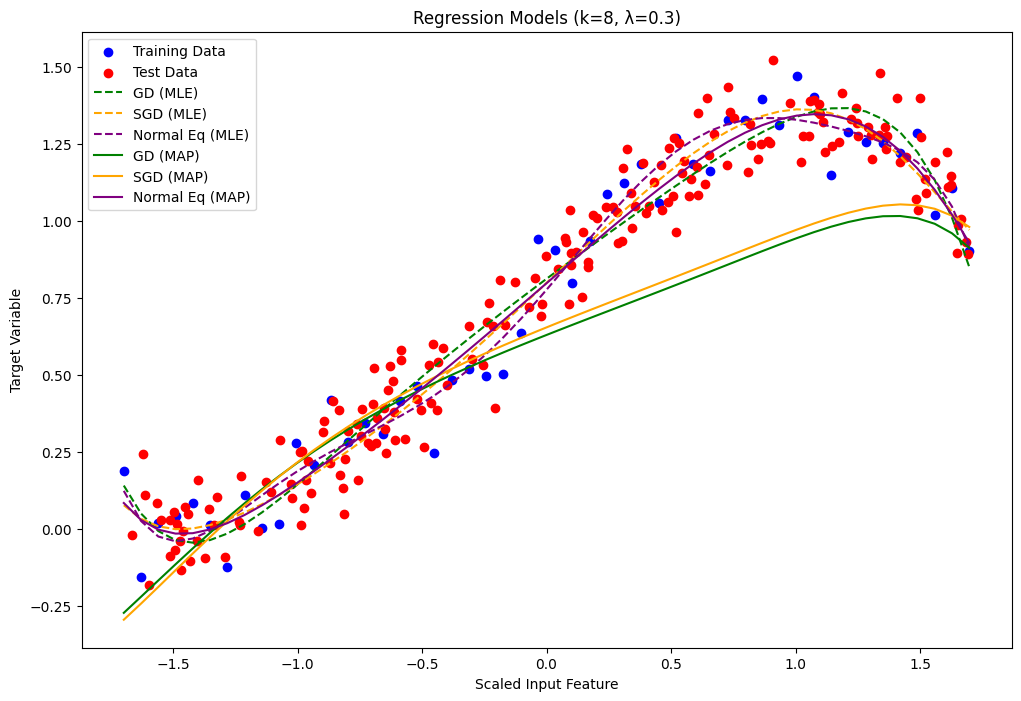

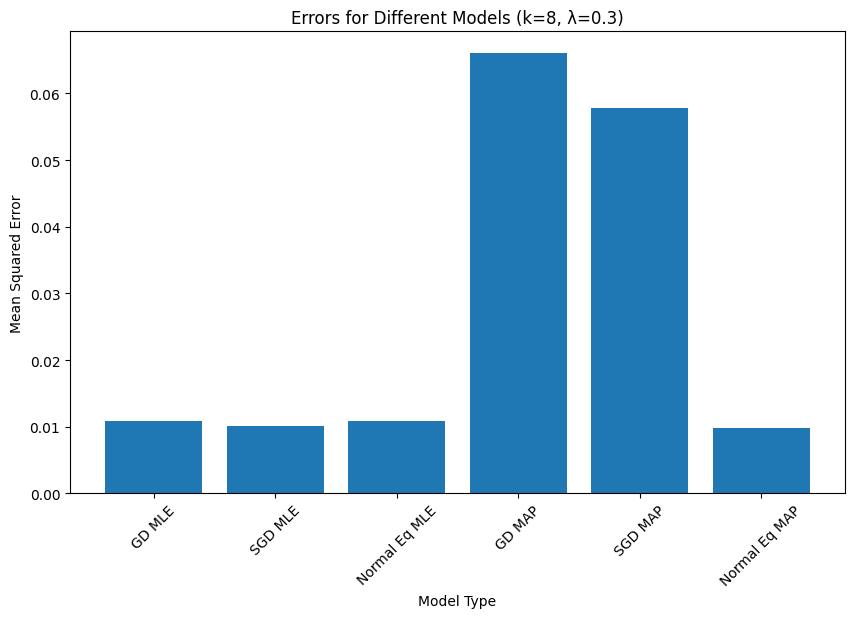

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Set polynomial degree and regularization parameter
k = 8
lambda_reg = 0.3

# Create polynomial features
X_train_poly = create_polynomial_features_m(X_train_scaled, k)
X_test_poly = create_polynomial_features_m(X_test_scaled, k)

# Train MLE models
theta_gd_mle, _ = gradient_descent(X_train_poly, y_train, lr=0.01, epochs=1000)
theta_sgd_mle, _ = stochastic_gradient_descent(X_train_poly, y_train, lr=0.01, epochs=1000, batch_size=5)
theta_ne_mle = normal_equations_cholesky_mle(X_train_poly, y_train)

# Train MAP models
theta_gd_map, _ = gradient_descent_map(X_train_poly, y_train, lr=0.01, epochs=1000, lambda_reg=lambda_reg)
theta_sgd_map, _ = stochastic_gradient_descent_map(X_train_poly, y_train, lr=0.01, epochs=1000, batch_size=5, lambda_reg=lambda_reg)
theta_ne_map = normal_equations_cholesky_map(X_train_poly, y_train, lambda_reg=lambda_reg)

# Compute predictions for training and test data
y_train_gd_mle = X_train_poly.dot(theta_gd_mle)
y_train_sgd_mle = X_train_poly.dot(theta_sgd_mle)
y_train_ne_mle = X_train_poly.dot(theta_ne_mle)
y_train_gd_map = X_train_poly.dot(theta_gd_map)
y_train_sgd_map = X_train_poly.dot(theta_sgd_map)
y_train_ne_map = X_train_poly.dot(theta_ne_map)

y_test_gd_mle = X_test_poly.dot(theta_gd_mle)
y_test_sgd_mle = X_test_poly.dot(theta_sgd_mle)
y_test_ne_mle = X_test_poly.dot(theta_ne_mle)
y_test_gd_map = X_test_poly.dot(theta_gd_map)
y_test_sgd_map = X_test_poly.dot(theta_sgd_map)
y_test_ne_map = X_test_poly.dot(theta_ne_map)

# Compute errors (Mean Squared Error)
def compute_error(X_poly, y, theta):
    predictions = X_poly.dot(theta)
    return np.mean((predictions - y) ** 2)

error_gd_mle = compute_error(X_test_poly, y_test, theta_gd_mle)
error_sgd_mle = compute_error(X_test_poly, y_test, theta_sgd_mle)
error_ne_mle = compute_error(X_test_poly, y_test, theta_ne_mle)

error_gd_map = compute_error(X_test_poly, y_test, theta_gd_map)
error_sgd_map = compute_error(X_test_poly, y_test, theta_sgd_map)
error_ne_map = compute_error(X_test_poly, y_test, theta_ne_map)

# Print errors for current degree k
print(f"Polynomial Degree k={k} , λ(for MAP)={lambda_reg}")
print(f"Error (GD MLE): {error_gd_mle}")
print(f"Error (SGD MLE): {error_sgd_mle}")
print(f"Error (Normal Eq MLE): {error_ne_mle}")
print(f"Error (GD MAP): {error_gd_map}")
print(f"Error (SGD MAP): {error_sgd_map}")
print(f"Error (Normal Eq MAP): {error_ne_map}")
print("-" * 30)

# Plot the models
plt.figure(figsize=(12, 8))

# Scatter training data
plt.scatter(X_train_scaled, y_train, color='blue', label='Training Data')
plt.scatter(X_test_scaled, y_test, color='red', label='Test Data')

# Plot MLE models on training data
plt.plot(X_train_scaled, y_train_gd_mle, label='GD (MLE)', color='green', linestyle='--')
plt.plot(X_train_scaled, y_train_sgd_mle, label='SGD (MLE)', color='orange', linestyle='--')
plt.plot(X_train_scaled, y_train_ne_mle, label='Normal Eq (MLE)', color='purple', linestyle='--')

# Plot MAP models on training data
plt.plot(X_train_scaled, y_train_gd_map, label='GD (MAP)', color='green')
plt.plot(X_train_scaled, y_train_sgd_map, label='SGD (MAP)', color='orange')
plt.plot(X_train_scaled, y_train_ne_map, label='Normal Eq (MAP)', color='purple')

# Add labels, title, and legend
plt.title(f'Regression Models (k={k}, λ={lambda_reg})')
plt.xlabel('Scaled Input Feature')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

# Plot the errors
error_labels = ['GD MLE', 'SGD MLE', 'Normal Eq MLE', 'GD MAP', 'SGD MAP', 'Normal Eq MAP']
errors = [error_gd_mle, error_sgd_mle, error_ne_mle, error_gd_map, error_sgd_map, error_ne_map]

plt.figure(figsize=(10, 6))
plt.bar(error_labels, errors,)
plt.title(f'Errors for Different Models (k={k}, λ={lambda_reg})')
plt.xlabel('Model Type')
plt.ylabel('Mean Squared Error')
plt.xticks(rotation=45)
plt.show()

as we can see for bigger values of lambda the polynomial is not good all the time and it can lead to inaccuracy instead of prevent overfitting , so its important to choose the right lambda